In [ ]:
import matplotlib.pyplot as plt
from matplotlib import pyplot
import matplotlib.dates as mdates
from matplotlib.colors import to_hex

import numpy as np
import json
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from os import walk
import re

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mutexa.rollingAvePlots import initialization

pyplot.rcParams['figure.dpi'] = 600
pyplot.rcParams['savefig.dpi'] = 600


def initialization(csvfile):
    countryGrouping = pd.read_csv(csvfile)
    countryGrouping = countryGrouping[['Sub-region Name', 'Country or Area']]
    country2region = {}
    for index, row in countryGrouping.iterrows():
        country2region[row.iloc[1]] = row.iloc[0]
    country2region['USA'] = 'Northern America'
    country2region['Taiwan'] = 'Eastern Asia'
    country2region['Hong Kong'] = 'Eastern Asia'
    country2region['United Kingdom'] = 'Northern Europe'
    country2region['South Korea'] = 'Eastern Asia'
    country2region['Vietnam'] = 'South-eastern Asia'
    country2region['Iran'] = 'Southern Asia'
    country2region['Czech Republic'] = 'Eastern Europe'
    country2region['Russia'] = 'Eastern Europe'
    country2region['Crimea'] = 'Eastern Europe'
    country2region['Brunei'] = 'South-eastern Asia'
    country2region['\u200eRomania'] = 'Eastern Europe'
    country2region['Venezuela'] = 'Latin America'
    country2region['Moldova'] = 'Eastern Europe'
    country2region['Reunion'] = 'Eastern Africa'
    country2region['Curacao'] = 'Latin America'
    country2region['Republic of Congo'] = 'Sub-Saharan Africa'
    country2region['Palestine'] = 'Western Asia'
    country2region['Saint Barthélemy'] = 'Latin America and the Caribbean'
    country2region['Saint Martin'] = 'Latin America and the Caribbean'
    country2region['CotedIvoire'] = 'Sub-Saharan Africa'
    country2region['Czech Repubic'] = 'Eastern Europe'
    country2region['St Eustatius'] = 'Latin America and the Caribbean'
    countryGrouping = pd.DataFrame.from_dict(country2region, orient='index')
    countryGrouping.columns = ['Region']
    countryGrouping.index.names = ['Country']
    return country2region, countryGrouping


In [ ]:
path = 'outputs/'
filenames = next(walk(path), (None, None, []))[2]  # [] if no file
relevant_files = [f for f in filenames if re
.compile('json|rolling').search(f)]
print(*relevant_files, sep='\n')

MPXV_country_min10_G91046A1.2_heatmapmatrix.json
MPXV_country_min10_T173050G1.2_heatmapmatrix.json
MPXV_country_min10_T73309C1.2_heatmapmatrix.json
MPXV_country_min10_T74384C1.2_heatmapmatrix.json
MPXV_country_min10_T74490A1.2_heatmapmatrix.json
MPXV_country_min10_Clade_B.1.21.2_heatmapmatrix.json
MPXV_country_min10_E5R1.2_heatmapmatrix.json
MPXV_country_min10_A73048C1.2_heatmapmatrix.json
MPXV_country_min10_T36032C1.2_heatmapmatrix.json
MPXV_country_min10_A152435-1.2_heatmapmatrix.json
MPXV_country_min10_G33133A1.2_heatmapmatrix.json
MPXV_country_min10_G144941A1.2_heatmapmatrix.json
MPXV_country_min10_T72777A1.2_heatmapmatrix.json
MPXV_country_min10_T33560C1.2_heatmapmatrix.json
MPXV_country_min10_A190465C1.2_heatmapmatrix.json
MPXV_country_min10_A33175G1.2_heatmapmatrix.json
MPXV_country_min10_T33112C1.2_heatmapmatrix.json
MPXV_country_min10_G149761T1.2_heatmapmatrix.json
MPXV_country_min10_G190289T1.2_heatmapmatrix.json
MPXV_country_min10_T144857A1.2_heatmapmatrix.json
MPXV_country_

In [ ]:
# Data
path = 'outputs/'
prefix = 'MPXV_country_min10'
group_name = 'country'
group = 'F8L'
threshold = 1.2

with open(path + prefix +"_" + group + str(threshold)+'_heatmapmatrix.json', 'r') as file:
    data = json.load(file)
heatmap = pd.DataFrame(data['z'], index=data['y'], columns=data['x'])

country2region, countryGrouping = initialization("/Users/lee349/Library/CloudStorage/OneDrive-CSIRO/Project related/StrEpiFun/mutexa/inputs/UNSD — Methodology.csv")
country2region, countryGrouping 

if group_name == 'country':
    heatmap['Region'] = heatmap.index.map(country2region)
    heatmap = heatmap.sort_values(['Region'])
    heatmap = heatmap.drop(['Region'], axis=1)
else:
    heatmap = heatmap.sort_index()

lineplot = pd.read_csv(path+ prefix +'_RollingAvg_mut' + group + '_t' + str(threshold)+'.csv')
line_melted = lineplot.melt(id_vars='Date', value_vars=lineplot.columns[1:], 
                    var_name=group_name, value_name='Value').sort_values(group_name)
line_melted


,Date,country,Value
1827,2022-01-03,Australia,NaN
1943,2022-04-29,Australia,NaN
1944,2022-04-30,Australia,NaN
1945,2022-05-01,Australia,NaN
1946,2022-05-02,Australia,NaN
...,...,...,...
2800,2022-09-03,United Kingdom,NaN
2801,2022-09-04,United Kingdom,NaN
2802,2022-09-05,United Kingdom,NaN
2804,2022-09-07,United Kingdom,NaN


['#b15928', '#ffff99', '#6a3d9a', '#ff7f00', '#fdbf6f', '#e31a1c', '#33a02c', '#b2df8a', '#1f78b4', '#a6cee3']


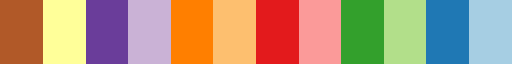

In [63]:
#Colour palette, max 10 categories to show
#from pypalettes import load_cmap, load_palette
#n = len(line_melted[group_name].unique())
n = 10
#cmap = load_cmap("Classic_Cyclic")
#palette = [to_hex(cmap(i / (n - 1))) for i in range(n)]
#palette

#OR use default
cmap = plt.get_cmap('Paired_r')
palette = [to_hex(cmap(i / (n - 1))) for i in range(n)]
print(palette)
cmap

#palette = ['#b15928', '#ffff99', '#6a3d9a', '#ff7f00', '#fdbf6f', '#e31a1c', '#33a02c', '#b2df8a', '#1f78b4', '#a6cee3']

In [100]:
# Nested labels: Country only or provide own dictionary
from matplotlib.patches import FancyArrowPatch
from collections import defaultdict

# group countries by continent preserving heatmap row order
from collections import defaultdict
continent_groups = defaultdict(list)
for i, country in enumerate(heatmap.index):
    continent_groups[country2region[country]].append(i)

/var/folders/lz/nv2zvbvj4_564xncwcwld59r0000gp/T/ipykernel_89564/3821931965.py:30: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.lineplot(data=line_melted, linewidth=1,x='Date', y='Value', hue=group_name, ax=axes[0], palette=palette)
/var/folders/lz/nv2zvbvj4_564xncwcwld59r0000gp/T/ipykernel_89564/3821931965.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


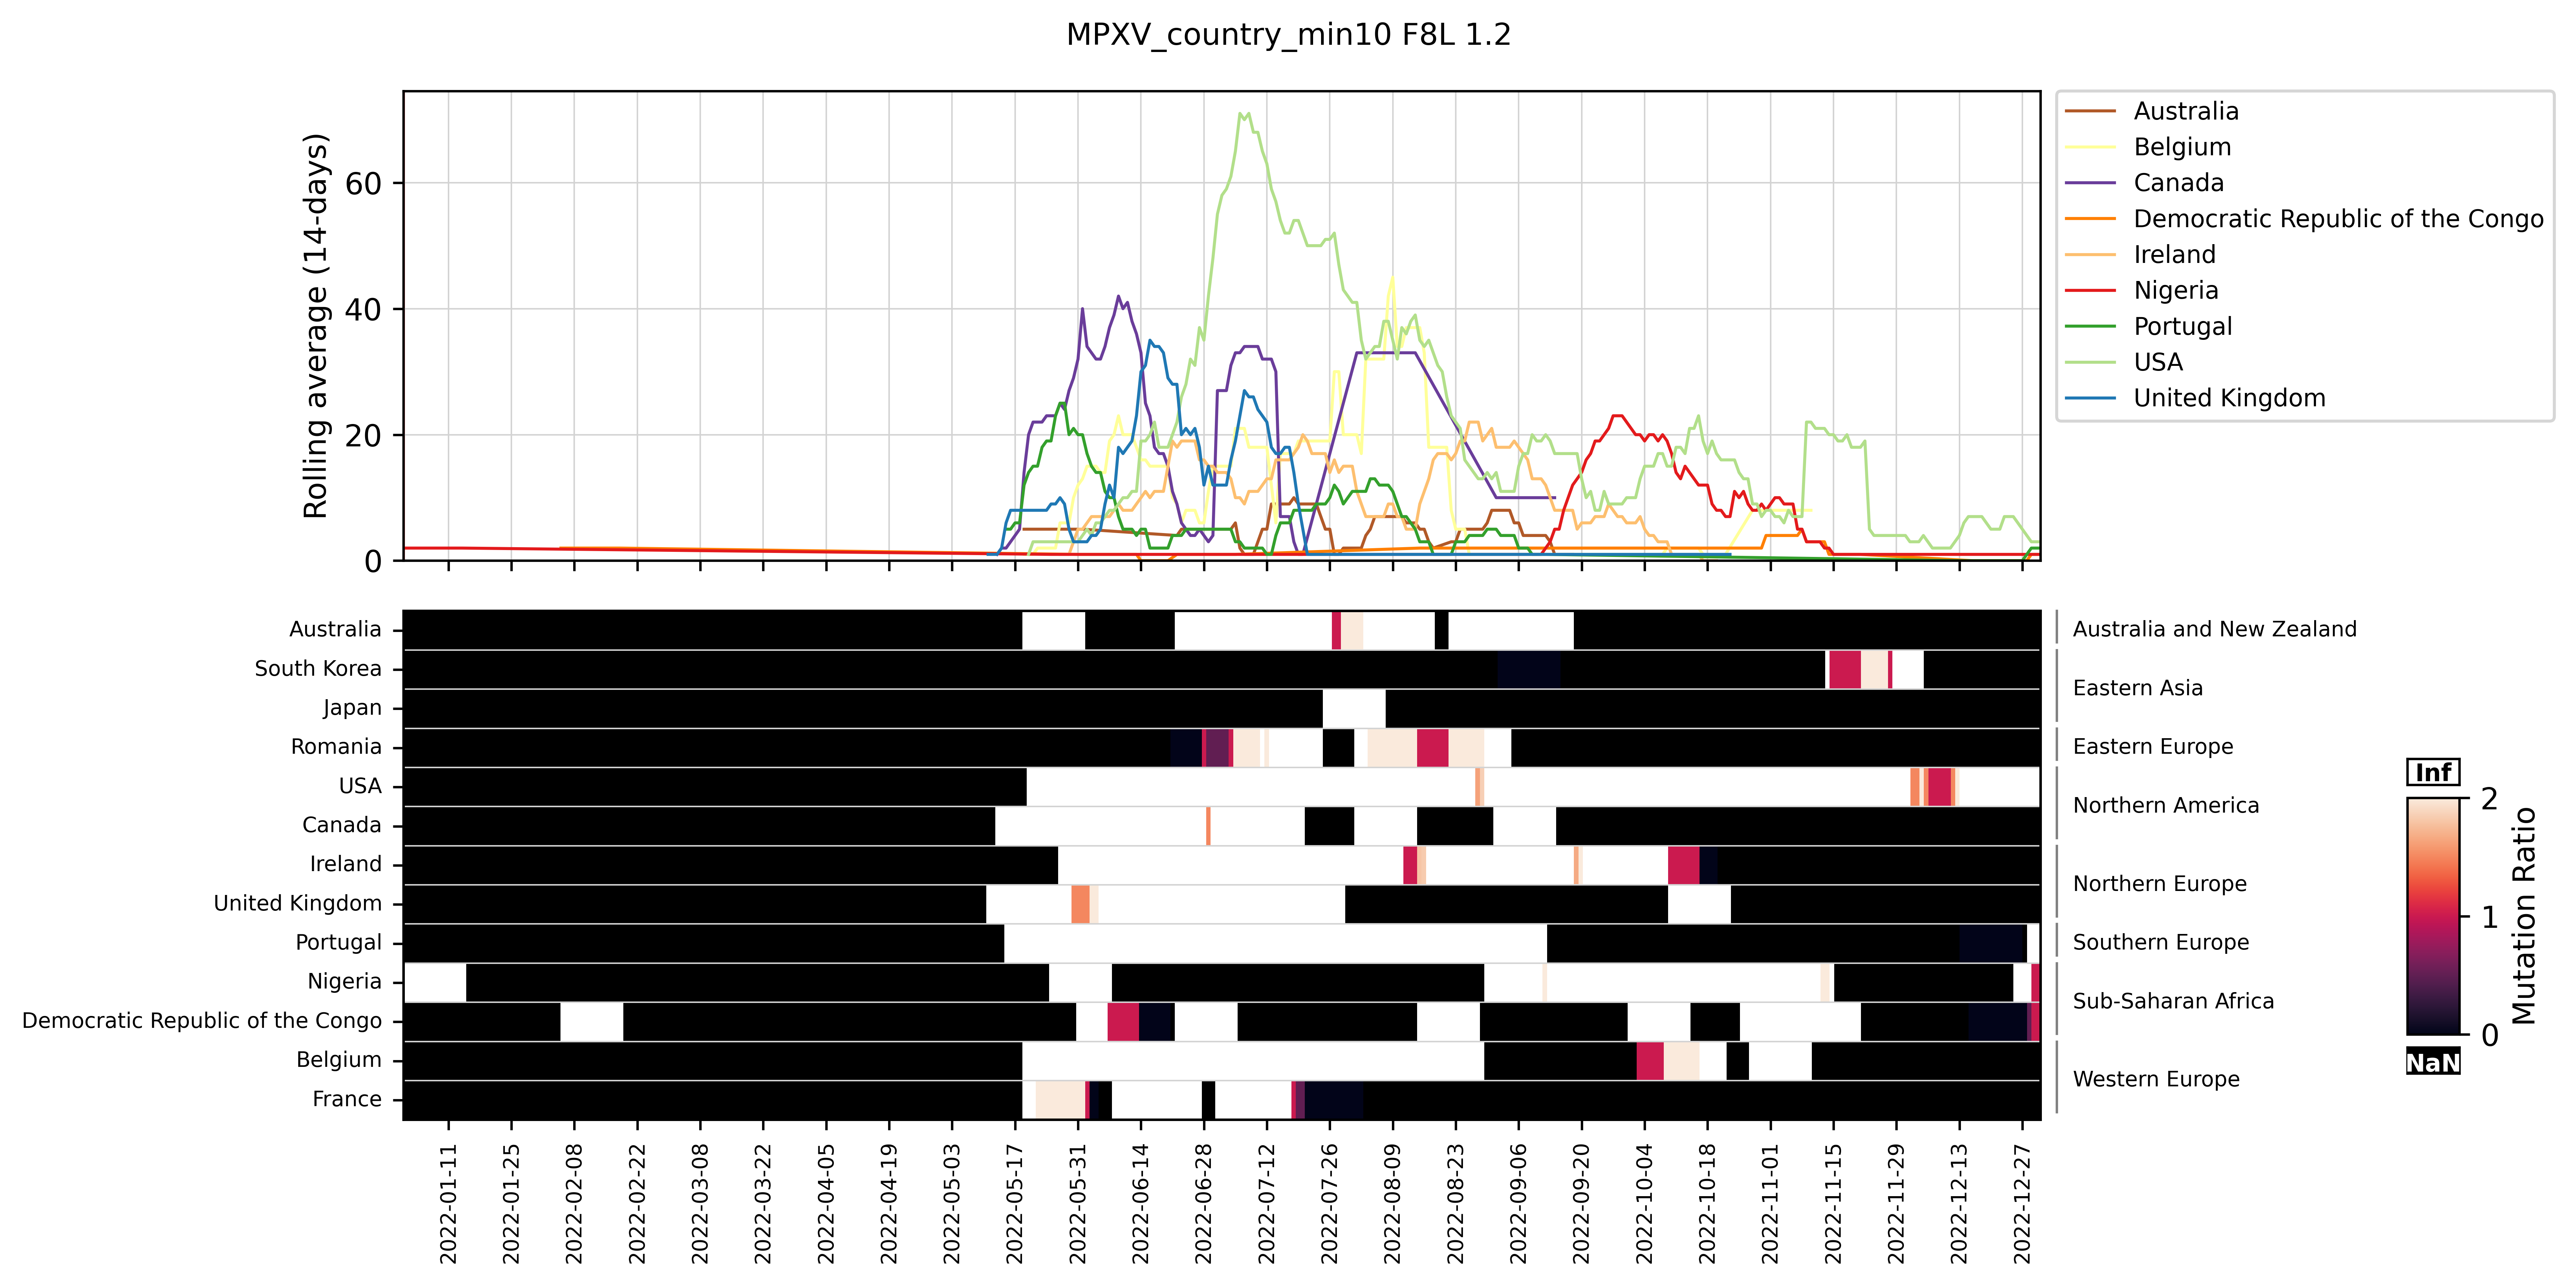

In [ ]:
line_melted['Date'] = pd.to_datetime(line_melted['Date'])
heatmap.columns = pd.to_datetime(heatmap.columns)

axis_fontsize=7
title_fontsize =10 
interval=2 # Weeks to display for each tick

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True,gridspec_kw={'height_ratios': [0.6, len(heatmap)*0.05]})
# Manual gridlines
axes[0].set_facecolor("white")
axes[0].grid(True, which="major", axis="y", color="lightgrey", linestyle="-", linewidth=0.5)
axes[0].grid(True, which="major", axis="x", color="lightgrey", linestyle="-", linewidth=0.5)

# after all axes[1] plotting code, add back heatmap background
axes[1].set_facecolor("black")
axes[1].grid(False)
axes[1].xaxis.grid(False)
axes[1].yaxis.grid(False)

# re-add separator line
for i in range(1, len(heatmap.index)):
    axes[1].axhline(y=i, color='lightgrey', linewidth=0.5)

#MinDate
minD= line_melted.loc[line_melted["Value"].astype(float) > 0]
mindate = minD.Date.min().date()
mindate

#Line plot
sns.lineplot(data=line_melted, linewidth=1,x='Date', y='Value', hue=group_name, ax=axes[0], palette=palette)
axes[0].set_ylabel("Rolling average (14-days)")
axes[0].tick_params(labelsize=10)
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=interval))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].set_ylim(bottom=0)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0,fontsize=8)
axes[0].axvspan(*mdates.datestr2num([str(mindate),str(mindate)]), color = 'red')

# heatmap with datetime axis
import matplotlib.dates as mdates
xmin = mdates.date2num(pd.to_datetime(heatmap.columns[0]))
xmax = mdates.date2num(pd.to_datetime(heatmap.columns[-1]))
heatmap_plot = heatmap.copy().astype(float)
heatmap_plot.replace([np.inf], 3, inplace=True)  # 3 is above vmax=2

cmap = sns.color_palette("rocket", as_cmap=True)
cmap.set_over('white')  # color for values above vmax (INF box)

im =  axes[1].imshow(heatmap_plot.values, aspect='auto', vmin=0, vmax=2,cmap=cmap,interpolation='none',
               extent=[xmin, xmax, len(heatmap), 0])
axes[1].xaxis_date()
#axes[1].set_yticks(range(len(heatmap.index)))
#axes[1].set_yticklabels(heatmap.index)
axes[1].set_facecolor("black")
axes[1].tick_params(labelsize=axis_fontsize)
axes[1].tick_params(axis='x', labelrotation=90)
axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
axes[1].set_yticklabels(heatmap.index, va='center')

# Heatmap legend
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.15]) #Left, bottom, width, height
#for i in range(1, len(heatmap.index)):
#    axes[1].axhline(y=i, color='w', linewidth=0.5)

# remove extend and handle inf manually
cbar = fig.colorbar(im, cax=cbar_ax)  # no extend
ticks = [0, 0.25, 0.5, 0.75, 1.0]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])

# add square above colorbar
cbar_pos = cbar_ax.get_position()
inf_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y1 + 0.01, 
                        cbar_pos.width, cbar_pos.width])  # square
inf_ax.set_facecolor('white')
inf_ax.set_xticks([])
inf_ax.set_yticks([])
inf_ax.text(0.5, 0.4, 'Inf', ha='center', va='center',
            color='black', fontsize=8, fontweight='bold',
            transform=inf_ax.transAxes)
# NaN square below colorbar
nan_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01,
                        cbar_pos.width, cbar_pos.width])  # square
nan_ax.set_facecolor('black')
nan_ax.set_xticks([])
nan_ax.set_yticks([])
nan_ax.text(0.5, 0.8, 'NaN', ha='center', va='top',
            color='white', fontsize=8, fontweight='bold',
            transform=nan_ax.transAxes)

fig.colorbar(im, cax=cbar_ax)
#pos = axes[1].get_position()
#cbar_ax = fig.add_axes([0.88, pos.y0 + pos.height * 0.25, 0.02, pos.height * 0.5])
cbar.set_label('Mutation Ratio', fontsize=10)
plt.suptitle(prefix + " "+  group + " "+ str(threshold), size=title_fontsize)
pos = axes[1].get_position()
cbar_height = pos.height * 0.5
cbar_bottom = pos.y0 + (pos.height - cbar_height) / 2

#cbar_ax.set_position([0.80, cbar_bottom, 0.02, cbar_height])
cbar_left = pos.x1 + 0.03
cbar_ax.set_position([cbar_left, cbar_bottom, 0.02, cbar_height])

cbar_pos = cbar_ax.get_position()

inf_ax.set_position([cbar_pos.x0, cbar_pos.y1 + 0.01, cbar_pos.width, cbar_pos.width])
nan_ax.set_position([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01, cbar_pos.width, cbar_pos.width])

# Continent axis
# set country labels
axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
axes[1].set_yticklabels(heatmap.index, va='center')

# add continent labels on a secondary y axis
ax2 = axes[1].twinx()
ax2.set_ylim(axes[1].get_ylim())
ax2.set_yticks([])

# Add secondary axis
for major, rows in continent_groups.items():
    mid = (min(rows) + max(rows) + 1) / 2  # midpoint of group
    ax2.text(1.02, mid, major, transform=ax2.get_yaxis_transform(),
             va='center', ha='left', fontsize=axis_fontsize,
             rotation=0)
    # draw a bracket line
    pad = 0.2
    ax2.plot([1.01, 1.01], [min(rows), max(rows) + 1 -pad],
             transform=ax2.get_yaxis_transform(),
             color='grey', linewidth=0.8, clip_on=False)

plt.subplots_adjust(right=0.85)
plt.tight_layout()

plt.savefig('outputs/' + prefix + "_" + group + "_" + str(threshold) + '.svg', dpi=600, bbox_inches='tight')
plt.show()
